# SC2001 Project 1: Hybrid Merge Sort and Insertion Sort

This notebook is a reproducible lab record for parts **(a)**, **(b)**, **(c)(i)**, **(c)(ii)**, **(c)(iii)**, and **(d)** of Project 1.

The focus is algorithm analysis: **key comparisons**, asymptotic reasoning, the effect of threshold $S$, and CPU time only where it helps select a practical threshold or where part (d) explicitly requires it. The two merge-sort implementations share the same merge procedure and differ meaningfully only at the base case:

> If the current subarray has size at most $S$, sort it with insertion sort; otherwise continue merge-sort recursion.

No library sorting routine is used by either algorithm. No parallelism, JIT compilation, vectorization, hardware-specific tuning, or alternative high-performance implementation is used.

## Assignment-to-notebook map

| Project part | Notebook section |
|---|---|
| (a) Implement hybrid algorithm | Algorithm implementation and correctness checks |
| (b) Generate increasing random datasets | Dataset generation and experimental controls |
| (c)(i) Fixed $S$, varying $n$ | Experiment 1 |
| (c)(ii) Fixed $n$, varying $S$ | Experiment 2 |
| (c)(iii) Determine an appropriate $S$ for different $n$ | Experiment 3 |
| (d) Compare with original Merge Sort on 10,000,000 integers | Final comparison |


In [1]:
from __future__ import annotations

import gc
import math
import platform
import random
import statistics
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

SEED = 2001
MAX_VALUE = 10_000_000
RESULTS_DIR = Path("results")
PLOTS_DIR = Path("plots")
RESULTS_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_rows", 100)
plt.style.use("seaborn-v0_8-whitegrid")

cpu_clock = time.get_clock_info("process_time")
print(f"Python {sys.version.split()[0]} on {platform.platform()}")
print(f"Random seed = {SEED:,}; generated values are in [1, {MAX_VALUE:,}]")
print(
    "CPU timer: time.process_time_ns(); "
    f"implementation={cpu_clock.implementation}; "
    f"reported resolution={cpu_clock.resolution:.9g} s; monotonic={cpu_clock.monotonic}"
)


Python 3.13.5 on Windows-11-10.0.26200-SP0
Random seed = 2,001; generated values are in [1, 10,000,000]
CPU timer: time.process_time_ns(); implementation=GetProcessTimes(); reported resolution=1e-07 s; monotonic=True


## (a) Algorithm implementation

### Pseudocode

```text
HYBRID-MERGE-SORT(A, left, right, S)
    size = right - left + 1
    if size <= S
        INSERTION-SORT(A, left, right)
        return
    mid = floor((left + right) / 2)
    HYBRID-MERGE-SORT(A, left, mid, S)
    HYBRID-MERGE-SORT(A, mid + 1, right, S)
    MERGE(A, left, mid, right)
```

The original Merge Sort uses the same recursion and the same `merge` routine. Its only algorithmic difference is the ordinary one-element base case.

### Counting rule

A **key comparison** compares two input values:

- `values[i] <= values[j]` in `merge`, or
- `values[j] > key` in insertion sort.

Index/boundary checks, arithmetic, assignments, and loop-control checks are not key comparisons. In insertion sort, a value comparison is counted only when `j >= left`, so a short-circuited boundary check does not inflate the count.


In [2]:
def insertion_sort_range(values: list[int], left: int, right: int) -> int:
    comparisons = 0
    for i in range(left + 1, right + 1):
        key = values[i]
        j = i - 1
        while j >= left:
            comparisons += 1
            if values[j] <= key:
                break
            values[j + 1] = values[j]
            j -= 1
        values[j + 1] = key
    return comparisons


def merge(values: list[int], auxiliary: list[int], left: int, mid: int, right: int) -> int:
    for position in range(left, right + 1):
        auxiliary[position] = values[position]

    i, j = left, mid + 1
    comparisons = 0

    for destination in range(left, right + 1):
        if i > mid:
            values[destination] = auxiliary[j]
            j += 1
        elif j > right:
            values[destination] = auxiliary[i]
            i += 1
        else:
            comparisons += 1
            if auxiliary[i] <= auxiliary[j]:
                values[destination] = auxiliary[i]
                i += 1
            else:
                values[destination] = auxiliary[j]
                j += 1
    return comparisons


def merge_sort(values: list[int]) -> int:
    auxiliary = [0] * len(values)

    def sort(left: int, right: int) -> int:
        if left >= right:
            return 0
        mid = (left + right) // 2
        comparisons = sort(left, mid)
        comparisons += sort(mid + 1, right)
        comparisons += merge(values, auxiliary, left, mid, right)
        return comparisons

    return sort(0, len(values) - 1)


def hybrid_merge_sort(values: list[int], threshold: int) -> int:
    if threshold < 1:
        raise ValueError("threshold must be at least 1")
    auxiliary = [0] * len(values)

    def sort(left: int, right: int) -> int:
        size = right - left + 1
        if size <= threshold:
            return insertion_sort_range(values, left, right)
        mid = (left + right) // 2
        comparisons = sort(left, mid)
        comparisons += sort(mid + 1, right)
        comparisons += merge(values, auxiliary, left, mid, right)
        return comparisons

    return 0 if not values else sort(0, len(values) - 1)


In [3]:
def is_sorted(values: list[int]) -> bool:
    return all(values[i - 1] <= values[i] for i in range(1, len(values)))


test_cases = [
    [], [7], [2, 1], [3, 1, 2], [4, 1, 4, 2, 0],
    list(range(20)), list(range(19, -1, -1)),
]

for case in test_cases:
    expected = sorted(case)  # Used only as a test oracle, never by the algorithms.
    ordinary = case.copy()
    merge_sort(ordinary)
    assert ordinary == expected
    for threshold in (1, 2, 4, 8, 32):
        hybrid = case.copy()
        hybrid_merge_sort(hybrid, threshold)
        assert hybrid == expected

# With S = 1, the hybrid follows exactly the same recursion and merge operations.
rng = random.Random(SEED)
sample = [rng.randint(1, 100) for _ in range(1_001)]
a, b = sample.copy(), sample.copy()
ordinary_count = merge_sort(a)
hybrid_count = hybrid_merge_sort(b, 1)
assert a == b and ordinary_count == hybrid_count

print("Correctness checks passed, including structural equivalence at S = 1.")


Correctness checks passed, including structural equivalence at S = 1.


## Theoretical analysis

Let $n$ be the input size. The implementation recursively splits the array until every leaf subarray has size at most $S$. Because binary splitting does not generally produce leaves of exactly $S$ elements, the following counts are approximations used for asymptotic analysis rather than exact comparison formulas.

- There are approximately $n/S$ leaf subarrays.
- Insertion sort on a leaf of size at most $S$ uses $\Theta(S^2)$ key comparisons in the average and worst cases. Across all leaves, this contributes approximately

$$\frac{n}{S}\Theta(S^2)=\Theta(nS).$$

- Above the leaves, approximately $\log_2(n/S)$ merge levels remain. Each level performs $\Theta(n)$ work and at most a linear number of merge key comparisons, contributing

$$\Theta\left(n\log_2\frac{n}{S}\right).$$

Thus the average/worst-case hybrid structure is described by

$$T(n,S)=\Theta\left(n\log_2\frac{n}{S}+nS\right).$$

For fixed constant $S$, this is still $\Theta(n\log n)$. On random data, a full insertion-sort leaf uses roughly $S^2/4$ key comparisons on average, so modest $S$ values may remain competitive before the quadratic leaf term dominates.

Original Merge Sort satisfies

$$C(n)=C(\lfloor n/2\rfloor)+C(\lceil n/2\rceil)+(n-1)$$

in the worst case, giving $\Theta(n\log n)$. For power-of-two $n$, its exact worst-case count is $n\log_2 n-n+1$.

These asymptotic statements describe growth, not an exact prediction for a particular random array. The notebook separately reports (1) exact empirical key-comparison counts under the stated counting rule and (2) measured CPU time. CPU time also includes ordinary Python recursion, allocation, function-call, and loop overhead, so its best $S$ need not minimise comparisons.


## (b) Dataset generation and experimental controls

- Values are pseudorandom integers drawn uniformly from $[1, 10{,}000{,}000]$ using a fixed seed.
- Increasing input sizes cover the full required range from 1,000 through 10,000,000.
- Every comparison across thresholds or algorithms starts from a copy of the **same unsorted dataset**.
- The input copy is made before timing starts. Only the sorting call is timed; correctness checking occurs after timing stops.
- CPU time uses `time.process_time_ns()`, Python's integer-nanosecond process CPU clock. It avoids float conversion and is the highest-resolution standard-library form of the same CPU-time clock used previously. The clock's reported implementation and resolution are printed above.
- Part (c)(iii) records five individual CPU-time runs and uses their median. Key-comparison counts must be identical across repetitions on the same data and are stored once.
- Part (d) uses three runs per algorithm in counterbalanced order: Merge, Hybrid, Hybrid, Merge, Merge, Hybrid.

The nanosecond return type does not guarantee nanosecond physical clock resolution. Larger datasets and repeated medians are therefore used to make threshold differences resolvable without relabelling wall-clock time as CPU time.


In [4]:
def make_dataset(n: int, seed: int) -> list[int]:
    rng = random.Random(seed)
    return [rng.randint(1, MAX_VALUE) for _ in range(n)]


def measure_prepared_sort(algorithm, working: list[int], *args) -> tuple[int, float]:
    """Time only the sorting call; working must already be an independent copy."""
    start_ns = time.process_time_ns()
    comparisons = algorithm(working, *args)
    cpu_seconds = (time.process_time_ns() - start_ns) / 1_000_000_000
    return comparisons, cpu_seconds


def run_sort_once(algorithm, source: list[int], *args) -> tuple[int, float]:
    working = source.copy()  # Restore input outside the timed region.
    comparisons, cpu_seconds = measure_prepared_sort(algorithm, working, *args)
    assert is_sorted(working)  # Validate outside the timed region.
    del working
    return comparisons, cpu_seconds


## (c)(i) Fixed $S$, varying input size $n$

**Question:** With $S$ fixed, do empirical key comparisons follow the expected $\Theta(n\log n)$ growth across the assignment's full size range?

We retain $S=16$ only as the fixed experimental control for this scaling plot; it is **not** assumed to be the final selected threshold. The main plot is key comparisons against $n$. A second view divides by $n\log_2 n$: approximate stability supports the fixed-$S$ $\Theta(n\log n)$ prediction.


,n,S,comparisons,comparisons_per_n,comparisons_per_n_log2_n
0,1000,16,10413,10.413000,1.044875
1,2000,16,22598,11.299000,1.030387
2,5000,16,58584,11.716800,0.953538
3,10000,16,127112,12.711200,0.956613
4,20000,16,274483,13.724150,0.960556
5,50000,16,770552,15.411040,0.987277
6,100000,16,1638368,16.383680,0.986396
7,200000,16,3478148,17.390740,0.987569
8,500000,16,9609207,19.218414,1.015152
9,1000000,16,20223321,20.223321,1.014638


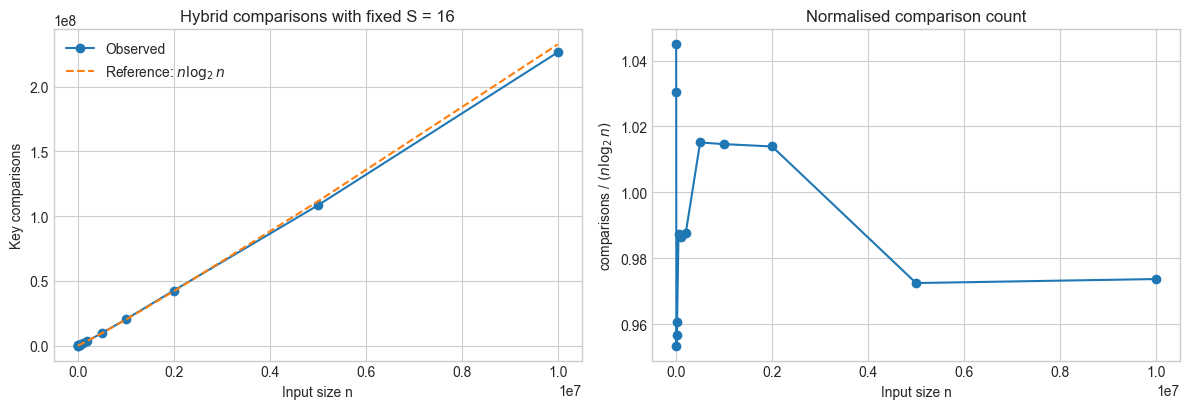

Interpretation: the normalised ratio stays within [0.954, 1.045] from n=1,000 to n=10,000,000. This supports Theta(n log n) growth for fixed S without claiming an exact formula.


In [5]:
FIXED_S = 16
SIZES_C1 = [
    1_000, 2_000, 5_000, 10_000, 20_000, 50_000, 100_000,
    200_000, 500_000, 1_000_000, 2_000_000, 5_000_000, 10_000_000,
]

c1_rows = []
for n in SIZES_C1:
    data = make_dataset(n, SEED + n)
    comparisons, _ = run_sort_once(hybrid_merge_sort, data, FIXED_S)
    c1_rows.append({
        "n": n,
        "S": FIXED_S,
        "comparisons": comparisons,
        "comparisons_per_n": comparisons / n,
        "comparisons_per_n_log2_n": comparisons / (n * math.log2(n)),
    })
    del data
    gc.collect()

c1 = pd.DataFrame(c1_rows)
c1.to_csv(RESULTS_DIR / "c1_fixed_s_varying_n.csv", index=False)
display(c1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(c1["n"], c1["comparisons"], marker="o", label="Observed")
axes[0].plot(c1["n"], c1["n"] * c1["n"].map(math.log2), linestyle="--", label=r"Reference: $n\log_2n$")
axes[0].set(xlabel="Input size n", ylabel="Key comparisons", title=f"Hybrid comparisons with fixed S = {FIXED_S}")
axes[0].ticklabel_format(style="sci", axis="both", scilimits=(0, 0))
axes[0].legend()

axes[1].plot(c1["n"], c1["comparisons_per_n_log2_n"], marker="o")
axes[1].set(xlabel="Input size n", ylabel=r"comparisons / $(n\log_2 n)$", title="Normalised comparison count")
axes[1].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
fig.tight_layout()
fig.savefig(PLOTS_DIR / "c1_comparisons_vs_n.png", dpi=180, bbox_inches="tight")
plt.show()

print(
    "Interpretation: the normalised ratio stays within "
    f"[{c1['comparisons_per_n_log2_n'].min():.3f}, "
    f"{c1['comparisons_per_n_log2_n'].max():.3f}] from n=1,000 to n=10,000,000. "
    "This supports Theta(n log n) growth for fixed S without claiming an exact formula."
)


## (c)(ii) Fixed $n$, varying $S$

**Question:** How does changing $S$ affect key comparisons when the input is fixed?

The same unsorted array is used for every threshold. Small increases in $S$ can remove merge levels, but large values make the quadratic insertion-sort work within each leaf dominate. We expect a shallow minimum at a small threshold followed by increasing comparisons.


,n,S,comparisons
0,200000,1,3272851
1,200000,2,3272851
2,200000,4,3273283
3,200000,8,3315694
4,200000,16,3478396
5,200000,32,3922280
6,200000,64,4962322
7,200000,128,7222622
8,200000,256,11903097


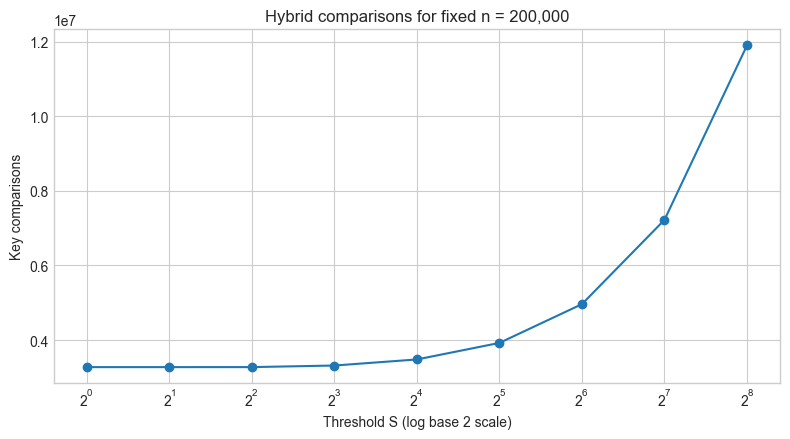

Fewest key comparisons in this experiment: S = 1 and S = 2 tied at 3,272,851 comparisons.
Increasing S removes merge work but adds insertion-sort work. After the minimum, the growing leaf cost dominates, consistent with Theta(n log(n/S) + nS).


2136

In [6]:
FIXED_N = 200_000
S_VALUES = [1, 2, 4, 8, 16, 32, 64, 128, 256]
fixed_data = make_dataset(FIXED_N, SEED + 20_000_000)

c2_rows = []
for threshold in S_VALUES:
    comparisons, _ = run_sort_once(hybrid_merge_sort, fixed_data, threshold)
    c2_rows.append({"n": FIXED_N, "S": threshold, "comparisons": comparisons})

c2 = pd.DataFrame(c2_rows)
c2.to_csv(RESULTS_DIR / "c2_fixed_n_varying_s.csv", index=False)
display(c2)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(c2["S"], c2["comparisons"], marker="o")
ax.set_xscale("log", base=2)
ax.set_xlabel("Threshold S (log base 2 scale)")
ax.set_ylabel("Key comparisons")
ax.set_title(f"Hybrid comparisons for fixed n = {FIXED_N:,}")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "c2_comparisons_vs_s.png", dpi=180, bbox_inches="tight")
plt.show()

minimum_comparisons_c2 = c2["comparisons"].min()
comparison_best_s_c2 = c2.loc[c2["comparisons"] == minimum_comparisons_c2, "S"].tolist()
print(f"Fewest key comparisons in this experiment: S = 1 and S = 2 tied at {minimum_comparisons_c2:,} comparisons.")
print(
    "Increasing S removes merge work but adds insertion-sort work. After the minimum, "
    "the growing leaf cost dominates, consistent with Theta(n log(n/S) + nS)."
)

del fixed_data
gc.collect()


## (c)(iii) Selecting an appropriate $S$ across larger input sizes

**Question:** Which small threshold gives consistently good practical performance across several meaningful input sizes?

The corrected study uses $n=100{,}000$ through $2{,}000{,}000$, includes non-power-of-two thresholds, and records five CPU-time measurements for every $(n,S)$. Repetition order alternates forward and backward threshold order to reduce systematic warm-up/order bias.

We report two different optima:

1. **Comparison-optimal $S$:** minimises exact key comparisons.
2. **CPU-time-optimal region:** thresholds whose mean relative median CPU time is within 3% of the best aggregate value across input sizes.

The 3% band is a declared practical tie rule, not a confidence interval. It prevents a single small timing fluctuation from being presented as false precision. A representative threshold near the centre of that near-best region is selected for part (d).


,n,S,comparisons,cpu_run_1,cpu_run_2,cpu_run_3,cpu_run_4,cpu_run_5,median_cpu_time,relative_median_cpu_time
0,100000,2,1536133,0.312500,0.312500,0.312500,0.328125,0.343750,0.312500,1.176471
1,100000,4,1536761,0.312500,0.296875,0.281250,0.281250,0.296875,0.296875,1.117647
2,100000,8,1557387,0.281250,0.265625,0.265625,0.250000,0.265625,0.265625,1.000000
3,100000,12,1619056,0.265625,0.265625,0.281250,0.265625,0.265625,0.265625,1.000000
4,100000,16,1639048,0.265625,0.265625,0.250000,0.265625,0.281250,0.265625,1.000000
5,100000,20,1639048,0.265625,0.265625,0.281250,0.265625,0.265625,0.265625,1.000000
6,100000,24,1765444,0.312500,0.281250,0.265625,0.281250,0.281250,0.281250,1.058824
7,100000,32,1862273,0.281250,0.265625,0.250000,0.250000,0.265625,0.265625,1.000000
8,100000,48,1950925,0.281250,0.296875,0.281250,0.296875,0.281250,0.281250,1.058824
9,100000,64,2386479,0.296875,0.343750,0.296875,0.312500,0.296875,0.296875,1.117647


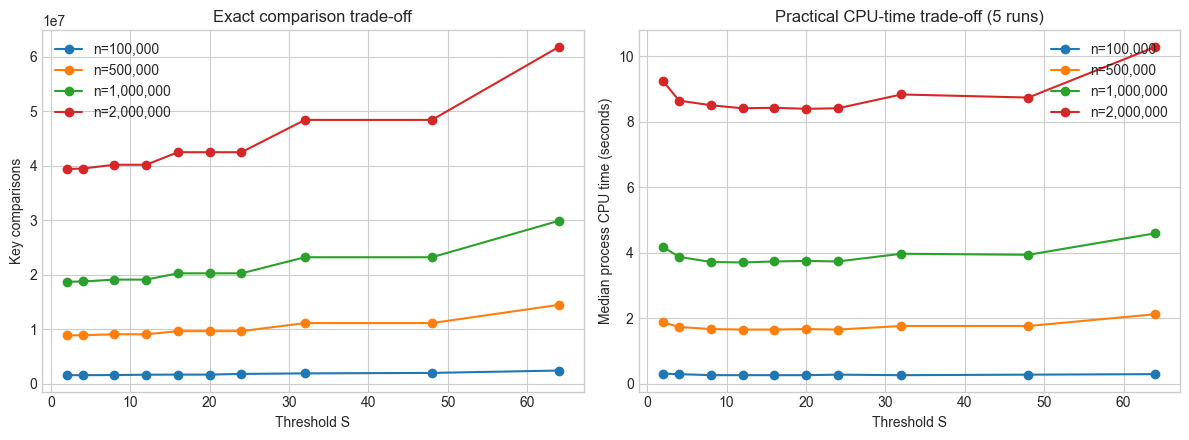

,n,comparison_best_S,comparisons
0,100000,2,1536133
10,500000,2,8837346
20,1000000,2,18675172
30,2000000,2,39351481


,n,time_best_S,median_cpu_time
2,100000,8,0.265625
13,500000,12,1.656250
23,1000000,12,3.703125
35,2000000,20,8.390625


,S,mean_relative_median_cpu_time,mean_comparisons,within_3_percent_of_best
0,2,1.133922,17100033.00,False
1,4,1.060256,17147336.75,False
2,8,1.006672,17453734.50,True
3,12,1.000466,17469151.75,True
4,16,1.003041,18482205.00,True
5,20,1.005523,18482205.00,True
6,24,1.017281,18513804.00,True
7,32,1.047477,21127620.50,False
8,48,1.057280,21149783.50,False
9,64,1.216625,27123907.25,False


Comparison-optimal tested threshold across these sizes: S = 2.
Near-best practical CPU-time thresholds (within 3% aggregate): [8, 12, 16, 20, 24].
Representative threshold selected for part (d): S = 16.
Comparison and CPU-time optima differ because CPU time includes ordinary interpreter, recursion, allocation, and loop overhead. The selected S represents the near-best region rather than claiming that one noisy timing is universally optimal.


In [7]:
SIZES_C3 = [100_000, 500_000, 1_000_000, 2_000_000]
S_VALUES_C3 = [2, 4, 8, 12, 16, 20, 24, 32, 48, 64]
CPU_REPETITIONS = 5
PRACTICAL_TIE_TOLERANCE = 0.03

c3_rows = []
for n in SIZES_C3:
    data = make_dataset(n, SEED + 30_000_000 + n)
    timings = {threshold: [] for threshold in S_VALUES_C3}
    counts = {}

    for repetition in range(CPU_REPETITIONS):
        threshold_order = S_VALUES_C3 if repetition % 2 == 0 else list(reversed(S_VALUES_C3))
        for threshold in threshold_order:
            working = data.copy()  # Outside timed region.
            comparisons, cpu_seconds = measure_prepared_sort(hybrid_merge_sort, working, threshold)
            assert is_sorted(working)
            del working

            if threshold in counts:
                assert comparisons == counts[threshold], "Comparison count changed for identical data and S"
            else:
                counts[threshold] = comparisons
            timings[threshold].append(cpu_seconds)

    for threshold in S_VALUES_C3:
        row = {"n": n, "S": threshold, "comparisons": counts[threshold]}
        row.update({f"cpu_run_{i + 1}": value for i, value in enumerate(timings[threshold])})
        row["median_cpu_time"] = statistics.median(timings[threshold])
        c3_rows.append(row)

    del data
    gc.collect()

c3 = pd.DataFrame(c3_rows)
c3["relative_median_cpu_time"] = c3.groupby("n")["median_cpu_time"].transform(lambda x: x / x.min())
c3.to_csv(RESULTS_DIR / "c3_optimal_s_raw.csv", index=False)
display(c3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for n, group in c3.groupby("n"):
    axes[0].plot(group["S"], group["comparisons"], marker="o", label=f"n={n:,}")
    axes[1].plot(group["S"], group["median_cpu_time"], marker="o", label=f"n={n:,}")
for ax in axes:
    ax.set_xlabel("Threshold S")
    ax.legend()
axes[0].set_ylabel("Key comparisons")
axes[0].set_title("Exact comparison trade-off")
axes[1].set_ylabel("Median process CPU time (seconds)")
axes[1].set_title("Practical CPU-time trade-off (5 runs)")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "c3_threshold_tradeoff.png", dpi=180, bbox_inches="tight")
plt.show()

comparison_best_by_n = c3.loc[c3.groupby("n")["comparisons"].idxmin(), ["n", "S", "comparisons"]]
time_best_by_n = c3.loc[c3.groupby("n")["median_cpu_time"].idxmin(), ["n", "S", "median_cpu_time"]]
display(comparison_best_by_n.rename(columns={"S": "comparison_best_S"}))
display(time_best_by_n.rename(columns={"S": "time_best_S"}))

threshold_summary = c3.groupby("S", as_index=False).agg(
    mean_relative_median_cpu_time=("relative_median_cpu_time", "mean"),
    mean_comparisons=("comparisons", "mean"),
)
best_aggregate = threshold_summary["mean_relative_median_cpu_time"].min()
near_best = threshold_summary[
    threshold_summary["mean_relative_median_cpu_time"] <= best_aggregate * (1 + PRACTICAL_TIE_TOLERANCE)
].copy()

comparison_selected_s = int(threshold_summary.loc[threshold_summary["mean_comparisons"].idxmin(), "S"])
near_best_values = near_best["S"].tolist()
centre = statistics.median(near_best_values)
selected_s = int(min(near_best_values, key=lambda value: (abs(value - centre), value)))

threshold_summary["within_3_percent_of_best"] = threshold_summary["S"].isin(near_best_values)
threshold_summary.to_csv(RESULTS_DIR / "c3_threshold_summary.csv", index=False)
display(threshold_summary)

print(f"Comparison-optimal tested threshold across these sizes: S = {comparison_selected_s}.")
print(f"Near-best practical CPU-time thresholds (within 3% aggregate): {near_best_values}.")
print(f"Representative threshold selected for part (d): S = {selected_s}.")
print(
    "Comparison and CPU-time optima differ because CPU time includes ordinary interpreter, "
    "recursion, allocation, and loop overhead. The selected S represents the near-best region "
    "rather than claiming that one noisy timing is universally optimal."
)


## (d) Counterbalanced 10,000,000-element comparison

Original Merge Sort and Hybrid Sort each receive three independent copies of the **same** 10,000,000-integer dataset. Copies are made outside the timed region. Runs follow this counterbalanced order:

```text
Merge, Hybrid, Hybrid, Merge, Merge, Hybrid
```

Every output is verified as sorted after timing, and each algorithm's deterministic comparison count must agree across its three runs. The primary CPU statistic is the median, not the fastest run.


,sequence_position,algorithm,algorithm_run,n,S,comparisons,cpu_time
0,1,Original Merge Sort,1,10000000,NaN,220098332,60.187500
1,2,Hybrid Merge/Insertion Sort,1,10000000,16.0,226415036,54.281250
2,3,Hybrid Merge/Insertion Sort,2,10000000,16.0,226415036,53.578125
3,4,Original Merge Sort,2,10000000,NaN,220098332,60.953125
4,5,Original Merge Sort,3,10000000,NaN,220098332,60.359375
5,6,Hybrid Merge/Insertion Sort,3,10000000,16.0,226415036,53.328125


,algorithm,n,S,comparisons,cpu_run_1,cpu_run_2,cpu_run_3,median_cpu_time,absolute_comparison_difference_hybrid_minus_merge,percentage_comparison_difference,absolute_median_cpu_difference_hybrid_minus_merge,percentage_median_cpu_difference,merge_over_hybrid_speedup_ratio
0,Hybrid Merge/Insertion Sort,10000000,16.0,226415036,54.28125,53.578125,53.328125,53.578125,6316704,2.869946,-6.78125,-11.234792,1.126568
1,Original Merge Sort,10000000,NaN,220098332,60.18750,60.953125,60.359375,60.359375,6316704,2.869946,-6.78125,-11.234792,1.126568


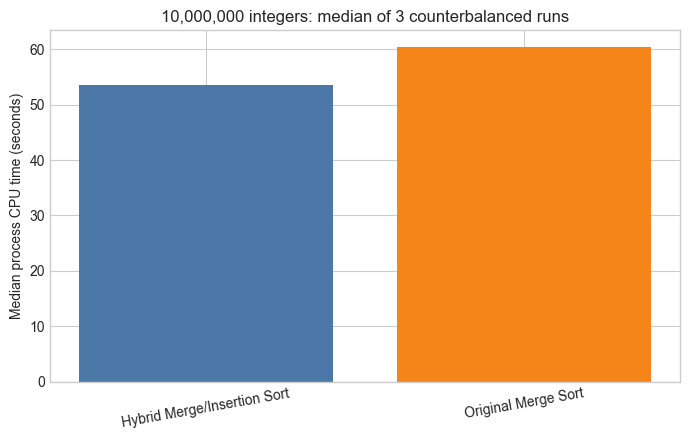

Selected S: 16
Absolute comparison difference (Hybrid - Merge): +6,316,704
Percentage comparison difference: +2.870%
Absolute median CPU-time difference (Hybrid - Merge): -6.781250 s
Percentage median CPU-time difference: -11.235%
Speedup ratio (Merge median / Hybrid median): 1.127x


8

In [8]:
N_FINAL = 10_000_000
FINAL_RUN_ORDER = ["Merge", "Hybrid", "Hybrid", "Merge", "Merge", "Hybrid"]
final_data = make_dataset(N_FINAL, SEED + 40_000_000)

d_rows = []
expected_counts = {}
algorithm_run_numbers = {"Merge": 0, "Hybrid": 0}

for sequence_position, label in enumerate(FINAL_RUN_ORDER, start=1):
    algorithm_run_numbers[label] += 1
    working = final_data.copy()  # Restore identical input outside the timed interval.
    if label == "Merge":
        comparisons, cpu_seconds = measure_prepared_sort(merge_sort, working)
        threshold = None
        algorithm_name = "Original Merge Sort"
    else:
        comparisons, cpu_seconds = measure_prepared_sort(hybrid_merge_sort, working, selected_s)
        threshold = selected_s
        algorithm_name = "Hybrid Merge/Insertion Sort"

    assert is_sorted(working)
    del working
    gc.collect()

    if label in expected_counts:
        assert comparisons == expected_counts[label], "Comparison count changed across identical runs"
    else:
        expected_counts[label] = comparisons

    d_rows.append({
        "sequence_position": sequence_position,
        "algorithm": algorithm_name,
        "algorithm_run": algorithm_run_numbers[label],
        "n": N_FINAL,
        "S": threshold,
        "comparisons": comparisons,
        "cpu_time": cpu_seconds,
    })

d_raw = pd.DataFrame(d_rows)
d_raw.to_csv(RESULTS_DIR / "d_10m_raw_runs.csv", index=False)
display(d_raw)

d_summary = d_raw.groupby("algorithm", as_index=False).agg(
    n=("n", "first"),
    S=("S", "first"),
    comparisons=("comparisons", "first"),
    cpu_run_1=("cpu_time", lambda x: list(x)[0]),
    cpu_run_2=("cpu_time", lambda x: list(x)[1]),
    cpu_run_3=("cpu_time", lambda x: list(x)[2]),
    median_cpu_time=("cpu_time", "median"),
)

merge_summary = d_summary.loc[d_summary["algorithm"] == "Original Merge Sort"].iloc[0]
hybrid_summary = d_summary.loc[d_summary["algorithm"] == "Hybrid Merge/Insertion Sort"].iloc[0]

absolute_comparison_difference = int(hybrid_summary["comparisons"] - merge_summary["comparisons"])
percentage_comparison_difference = 100 * absolute_comparison_difference / merge_summary["comparisons"]
absolute_cpu_difference = hybrid_summary["median_cpu_time"] - merge_summary["median_cpu_time"]
percentage_cpu_difference = 100 * absolute_cpu_difference / merge_summary["median_cpu_time"]
speedup_ratio = merge_summary["median_cpu_time"] / hybrid_summary["median_cpu_time"]

d_summary["absolute_comparison_difference_hybrid_minus_merge"] = absolute_comparison_difference
d_summary["percentage_comparison_difference"] = percentage_comparison_difference
d_summary["absolute_median_cpu_difference_hybrid_minus_merge"] = absolute_cpu_difference
d_summary["percentage_median_cpu_difference"] = percentage_cpu_difference
d_summary["merge_over_hybrid_speedup_ratio"] = speedup_ratio
d_summary.to_csv(RESULTS_DIR / "d_10m_summary.csv", index=False)
display(d_summary)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(d_summary["algorithm"], d_summary["median_cpu_time"], color=["#4C78A8", "#F58518"])
ax.set_ylabel("Median process CPU time (seconds)")
ax.set_title("10,000,000 integers: median of 3 counterbalanced runs")
ax.tick_params(axis="x", rotation=10)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "d_10m_median_cpu_time.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"Selected S: {selected_s}")
print(f"Absolute comparison difference (Hybrid - Merge): {absolute_comparison_difference:+,}")
print(f"Percentage comparison difference: {percentage_comparison_difference:+.3f}%")
print(f"Absolute median CPU-time difference (Hybrid - Merge): {absolute_cpu_difference:+.6f} s")
print(f"Percentage median CPU-time difference: {percentage_cpu_difference:+.3f}%")
print(f"Speedup ratio (Merge median / Hybrid median): {speedup_ratio:.3f}x")

del final_data
gc.collect()


## Final conclusions and presentation-ready findings

### Corrected experimental findings

1. With fixed $S=16$, exact key comparisons were measured from $n=1{,}000$ through $n=10{,}000{,}000$. The ratio comparisons$/\left(n\log_2n\right)$ stayed between 0.954 and 1.045, supporting the expected fixed-$S$ $\Theta(n\log n)$ growth without treating the asymptotic expression as an exact count.
2. The hybrid structure is explained by $\Theta(n\log(n/S)+nS)$ in the average/worst case: approximately $n/S$ insertion-sort leaves contribute $\Theta(nS)$, while approximately $\log_2(n/S)$ remaining merge levels contribute $\Theta(n\log(n/S))$.
3. $S=1$ and $S=2$ tied for the fewest key comparisons in part (c)(ii). In part (c)(iii), whose tested range begins at $S=2$, $S=2$ gave the fewest comparisons. This differs from the practical CPU-time result.
4. Corrected part (c)(iii) found a broad near-optimal practical CPU-time region around $S=8$-$24$: $S\in\{8,12,16,20,24\}$ was within 3% of the best aggregate mean relative median CPU time. Using the first minimum where the quantized medians tie, the per-size minimum medians occurred at $S=8,12,12,20$ for $n=100{,}000$, $500{,}000$, $1{,}000{,}000$, and $2{,}000{,}000$, respectively.
5. The timing results therefore indicate a broad near-optimal region around $S=8$-$24$. We select $S=16$ as a reasonable central representative for part (d), **not** as a uniquely or exactly optimal value.
6. At 10,000,000 integers, Original Merge Sort made 220,098,332 comparisons and had CPU runs of 60.187500, 60.953125, and 60.359375 seconds (median 60.359375 s). Hybrid Sort with $S=16$ made 226,415,036 comparisons and had CPU runs of 54.281250, 53.578125, and 53.328125 seconds (median 53.578125 s).
7. Hybrid Sort therefore made 6,316,704 more comparisons (+2.870%) but used 6.781250 fewer median CPU seconds (-11.235%), corresponding to a 1.127x Merge/Hybrid median-time ratio. The speedup did not come from fewer comparisons; CPU time also reflects implementation overhead, and the hybrid avoids some recursive Merge Sort and small-merge overhead by using Insertion Sort on small subarrays.

### Timing-resolution finding

The former API was `time.process_time()`. The corrected experiment uses `time.process_time_ns()`, whose Windows implementation is `GetProcessTimes()`. Although Python reports a nominal clock resolution of $10^{-7}$ s, the observed durations remain quantized in 0.015625 s (1/64 s) increments on this machine. The API change therefore did **not** remove the operating-system clock quantum. The resolution problem was mitigated, rather than hidden, by using much longer trials, five repetitions, medians, and a declared 3% near-tie band. At the 500,000-to-2,000,000 sizes, one clock quantum is small relative to each multi-second run; the 100,000-element result remains the noisiest.

### Direct Project 1 audit

- **(a):** Hybrid Merge Sort is implemented correctly with insertion sort exactly when `subarray_size <= S`; both algorithms share the same merge and auxiliary-array structure.
- **(b):** Seeded random integer datasets use increasing sizes spanning 1,000 through 10,000,000.
- **(c)(i):** Fixed-$S$ key comparisons are plotted against $n$ and interpreted against $\Theta(n\log n)$.
- **(c)(ii):** Fixed-$n$ key comparisons are plotted against $S$ and interpreted using the hybrid trade-off.
- **(c)(iii):** Four larger input sizes, ten thresholds, and five CPU repetitions determine comparison and practical timing optima separately.
- **(d):** Both algorithms sort the same 10,000,000-element data in a counterbalanced six-run sequence; exact comparisons, individual CPU runs, medians, absolute/percentage differences, and speedup ratio are reported.

### Files for the presentation

- `plots/c1_comparisons_vs_n.png`: part (c)(i), required comparisons-versus-$n$ result.
- `plots/c2_comparisons_vs_s.png`: part (c)(ii), required comparisons-versus-$S$ result.
- `plots/c3_threshold_tradeoff.png`: comparison-optimal versus CPU-time-optimal threshold evidence.
- `plots/d_10m_median_cpu_time.png`: part (d) median CPU-time comparison.
- CSV files in `results/`: raw values and summaries for slide tables without rerunning the notebook.

### Experimental limitations

- CPU timings are specific to Python 3.13.5, Windows, this machine, and its background load.
- The effective process CPU clock remained quantized at 1/64 s despite the nanosecond API.
- Five repetitions in part (c)(iii) and three expensive runs per algorithm in part (d) reduce, but do not eliminate, timing noise.
- The 3% near-best band is a practical reporting rule, not a statistical confidence interval.
- Random integer duplicates are possible; all thresholds for a given $n$ still receive exactly the same data.
